Compute mean connectivity from HCP7T dataset

In [1]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from glob import glob

In [2]:
tian_scale = 'S2'

lut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-carpet',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-carpet_lut.tsv')

region_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])

In [3]:
region_list

['aPUT-lh',
 'pPUT-lh',
 'aCAU-lh',
 'pCAU-lh',
 'aPUT-rh',
 'pPUT-rh',
 'aCAU-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp',
 'L-LOCsup',
 'L-LOCinf',
 'L-IntraCalc',
 'L-TempOccFus',
 'L-OccFus',
 'L-SupraCalc',
 'L-OccPole',
 'R-LOCsup',
 'R-LOCinf',
 'R-IntraCalc',
 'R-TempOccFus',
 'R-OccFus',
 'R-SupraCalc',
 'R-OccPole']

In [4]:
data_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                        'HCP_7T_diffusion/msmt_csd_nthreads-1/')

## Read in participant connectivity matrices

In [5]:
print(data_dir + 
      '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv')

/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1//*/connectome_streamlines_alg-iFOD2_nsl-10mil/atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv


In [6]:
conn_files = sorted(glob(data_dir + 
                         '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         f'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv'))

# derive participant IDs directly from conn_files (preserves same order)
participants_with_files = sorted(list({os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(p)))) for p in conn_files}))


In [7]:
print(len(conn_files))

96


In [8]:
test_df = pd.read_csv(conn_files[0], header=None)
print(test_df)
print(len(test_df))


             0            1            2            3            4   \
0   8268.074209  3171.177498  2156.096386   828.728846    80.337416   
1   3171.177498  3677.825174   304.758787  1126.495766    67.175016   
2   2156.096386   304.758787  8997.764935  1554.796652    69.710324   
3    828.728846  1126.495766  1554.796652  3014.341623    30.107019   
4     80.337416    67.175016    69.710324    30.107019  9985.398348   
5    105.360801   189.179635    15.751270    97.746538  3218.237984   
6     24.730155    10.277543    31.992937    21.574194  3155.990691   
7     27.268470    21.221287    19.345882    51.452262   237.809434   
8     65.834432  3104.246460     4.357843    19.704495     0.280541   
9   1039.054971  4790.470911    32.089380    63.850731    17.240047   
10   285.033913  1161.845649    29.873710    63.258076     0.000000   
11    17.673466   303.012608     1.401305     5.224105     0.000000   
12    85.995214   168.422050     7.799678    23.021013     0.000000   
13    

In [9]:
# loop through each subject's connectivity matrix and clean up the formatting
num_regions = len(test_df) # number of regions of interest in the HCP analysis
num_subjects = len(conn_files)
connmats = np.zeros((num_subjects, num_regions, num_regions))
slcounts = np.zeros((num_regions, num_subjects))
list_df = []
for sx, matrix_fpath in enumerate(conn_files):

    sub_df = pd.read_csv(matrix_fpath, header=None)
    list_df.append(sub_df)
    
    connmats[sx,:,:] = sub_df.to_numpy()
    
    slcounts[:,sx] = sub_df.to_numpy().sum(axis=0) # sub_df.iloc[:,0]

In [10]:
np.shape(connmats)

(96, 32, 32)

In [11]:
# check the streamline count matrix (region x subject)
slcounts

array([[ 17654.9239572 ,  12343.8669304 ,  16232.06786203, ...,
          9811.90286273,  11551.08338089,  11118.79614892],
       [ 28763.03932369,  24509.68719753,  33928.22103077, ...,
         25780.12580422,  29324.91321199,  29391.99721096],
       [ 13334.93881819,   3813.52467205,   6333.83022261, ...,
          6482.43640889,  11118.59499137,   6734.14969368],
       ...,
       [136109.86204942, 131451.11719377,  87470.99990673, ...,
        121563.7135299 , 103697.94411707, 158189.48620456],
       [ 14667.26548672,  20544.41618498,  27905.65710887, ...,
         11498.53072113,  15725.83892688,  10288.82181464],
       [177609.96160817, 123138.86416979, 128152.53859879, ...,
        100206.4379721 ,  71140.83812641, 114135.52991529]])

In [12]:
slcounts[0,:]

array([17654.9239572 , 12343.8669304 , 16232.06786203, 13410.62555215,
       11009.37242214,  9137.94657102, 13404.42472865, 11046.58353871,
       13268.56021566, 14441.2994114 , 14237.12723292, 18150.7004613 ,
       10718.60777433, 17989.32578655,  9348.83684602, 15393.23144746,
       14362.90942782,  4577.19069234, 10495.23114571, 13720.48022154,
       10073.10763173, 17668.95768075, 11840.07966646, 13631.03860167,
       12505.46168888, 21191.8492417 , 15962.26417977, 14464.41730876,
       11601.67333616, 15000.25794815,  9866.14231026, 11106.35985003,
       11584.59282801, 12171.39707649, 10157.28640474, 13696.59648146,
       13037.30789647,  8930.40126659, 12997.2390027 , 15915.87316255,
       10920.18799369, 11605.93532081, 10120.50196044,  8630.78626287,
       15788.16341707,  7938.75282776, 12008.52170353, 10693.99694252,
       14297.407125  , 14857.74287306,  7284.05413003, 12872.1133633 ,
       13832.09850551, 16168.14700159,  8447.53355555, 10899.19938154,
      

In [13]:
slcounts[4,:]

array([20051.54382485, 15450.57091168, 16336.09042089, 14627.37181404,
       14544.13878065, 13104.16674583, 10167.51491806, 11985.34560542,
       15031.42929357, 12287.73388626, 19875.03496788, 22647.93582135,
       12583.85912532, 22840.76176298, 14328.64528707, 17773.36485226,
       15276.9719341 ,  4992.57927646, 22290.84267941, 17581.90634017,
       13887.61795105, 14697.24472044, 13350.08734661, 20294.502167  ,
       18988.63010661, 21388.78554468, 17181.16323335, 26453.64029567,
       10603.93405305, 16036.18973537, 11355.30151994, 11139.43500854,
       13801.97814973, 16486.52840172, 14999.69982012, 15929.03777464,
       13416.15681084, 12258.33055796, 15443.34613613, 18766.0428279 ,
       12802.54289262, 17573.57704641, 15068.67547999,  9757.96347558,
       15478.140568  , 10554.67848825, 23354.34261672, 15867.18685739,
       15155.64921209, 13688.91512718, 12505.15890601, 15834.23407872,
       12531.47960804, 17423.24742846,  9074.63274036, 12073.54072176,
      

## Compute mean streamline count per ROI

In [14]:
# compute the mean streamline count per IC subdivision
mean_slcount = slcounts.mean(axis=1)
print(mean_slcount)
print(mean_slcount.shape)

[ 12496.57523319  25237.35089735   7851.11057802   5469.20563153
  15758.03485555  28045.16721332   8580.06767804   7084.28602781
  31138.39861572  39915.62196691  53071.23070819  29749.3447293
  43975.28375636  30226.34634097  34048.49835025  47426.35879302
  18268.85416923  55617.39741986 212570.166592   126478.11339862
  58530.98324191  66301.36936387      0.          21933.51250449
 178431.71096165 181189.24513781 126264.16652245  58316.64468227
  60444.18258403 115698.48228528  17430.83669288 123946.29532795]
(32,)


In [15]:
mean_connmat = connmats.mean(axis=0)

print(mean_connmat)
print(mean_connmat.shape)

[[4.59476824e+03 2.29650020e+03 1.38291192e+03 ... 8.38191365e+02
  1.11697769e-01 3.20936932e-02]
 [2.29650020e+03 3.46458857e+03 1.73184216e+02 ... 9.78434720e+02
  3.66743371e+00 2.82323588e+00]
 [1.38291192e+03 1.73184216e+02 4.52374674e+03 ... 2.91587869e+01
  2.47836608e-01 0.00000000e+00]
 ...
 [8.38191365e+02 9.78434720e+02 2.91587869e+01 ... 5.08280633e+04
  3.28692612e+01 2.08388150e+01]
 [1.11697769e-01 3.66743371e+00 2.47836608e-01 ... 3.28692612e+01
  1.96786389e+03 2.46564361e+03]
 [3.20936932e-02 2.82323588e+00 0.00000000e+00 ... 2.08388150e+01
  2.46564361e+03 6.71242878e+04]]
(32, 32)


In [16]:

# add ROI names to df
mean_df = pd.DataFrame(mean_connmat, columns=region_list)
mean_df.insert(0, 'seed', region_list)
mean_df.insert(0, 'mean_slcount', mean_slcount)


In [17]:
mean_df

,mean_slcount,seed,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,12496.575233,aPUT-lh,4594.768244,2296.500200,1382.911924,322.442604,22.237481,19.164801,25.692593,17.985184,...,0.0,23.630628,190.674613,0.018868,0.034657,1.009704,4.452160,838.191365,0.111698,0.032094
1,25237.350897,pPUT-lh,2296.500200,3464.588573,173.184216,780.437277,16.660306,47.506231,9.500343,23.952236,...,0.0,63.615859,2819.797004,4.968890,0.003099,5.039982,4.294761,978.434720,3.667434,2.823236
2,7851.110578,aCAU-lh,1382.911924,173.184216,4523.746743,1440.836322,22.550421,12.147108,82.526913,30.867949,...,0.0,6.022249,0.005728,0.209947,0.007468,1.728977,0.927188,29.158787,0.247837,0.000000
3,5469.205632,pCAU-lh,322.442604,780.437277,1440.836322,2301.844167,18.136322,41.279017,38.353878,84.727464,...,0.0,2.902015,9.637456,0.824570,0.038673,0.272413,0.440802,6.667765,0.171591,0.007212
4,15758.034856,aPUT-rh,22.237481,16.660306,22.550421,18.136322,6198.886447,2730.528290,1218.398545,231.024629,...,0.0,0.100879,0.002759,919.872631,350.464054,444.140011,145.031980,1.720129,18.160533,340.629033
5,28045.167213,pPUT-rh,19.164801,47.506231,12.147108,41.279017,2730.528290,3616.149493,194.010544,783.268510,...,0.0,8.832582,0.490100,5733.606187,742.272250,421.466897,212.796559,0.170296,37.500737,3198.059812
6,8580.067678,aCAU-rh,25.692593,9.500343,82.526913,38.353878,1218.398545,194.010544,4437.258785,2405.191184,...,0.0,0.050639,0.003282,28.498469,5.013922,13.055342,11.731764,0.249517,1.613782,0.099784
7,7084.286028,pCAU-rh,17.985184,23.952236,30.867949,84.727464,231.024629,783.268510,2405.191184,3031.819303,...,0.0,0.069344,0.000000,212.612842,16.358547,5.051190,4.789006,0.004806,0.635214,5.567816
8,31138.398616,L-HG,96.787652,3107.375017,5.701020,7.244493,0.032247,3.183114,0.141974,0.408688,...,0.0,8.322473,25.473017,3.473581,0.003009,1.094249,0.095339,8.286650,1.069561,0.026044
9,39915.621967,L-PP,1027.428643,4216.621598,48.354740,84.135012,3.685588,4.764960,2.288174,2.340054,...,0.0,59.882857,1549.279797,0.269672,0.000000,2.469623,0.355285,836.630977,1.172329,1.636712


In [18]:
# save the mean data
out_dir = os.path.join(data_dir, 'group_plots_Apr')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity.txt')
os.makedirs(out_dir, exist_ok=True)
mean_df.to_csv(out_fpath, sep='\t', index=False)

In [19]:
out_dir

'/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/group_plots_Apr'

### Plot distributions

In [20]:
import seaborn as sns

In [21]:
connmats.shape

(96, 32, 32)

<Axes: >

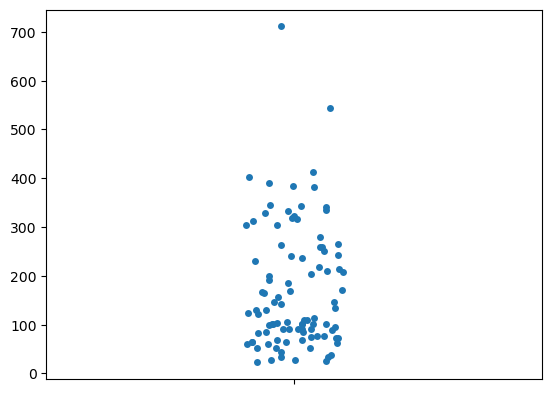

In [22]:
sns.stripplot(connmats[:,1,2])

## Combine separate participants into single dataframe

In [49]:
num_participants = len(connmats)
print('Number of participants:', num_participants)

Number of participants: 96


In [24]:
connmats.shape

(96, 32, 32)

In [25]:
m,n,r = connmats.shape

out_arr = np.column_stack((np.repeat(np.arange(m),n),connmats.reshape(m*n,-1)))
out_df = pd.DataFrame(out_arr)

In [26]:
out_df

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,0.0,8268.074209,3171.177498,2156.096386,828.728846,80.337416,105.360801,24.730155,27.268470,65.834432,...,0.0,23.155169,2.868346,0.000000,0.000000,0.252881,12.347968,701.134879,0.000000,0.000000
1,0.0,3171.177498,3677.825174,304.758787,1126.495766,67.175016,189.179635,10.277543,21.221287,3104.246460,...,0.0,64.950453,3254.238021,0.000000,0.000000,4.944340,1.153351,986.246182,1.263524,4.618848
2,0.0,2156.096386,304.758787,8997.764935,1554.796652,69.710324,15.751270,31.992937,19.345882,4.357843,...,0.0,6.370223,0.000000,0.000000,0.000000,1.677651,1.864382,24.140525,0.818620,0.000000
3,0.0,828.728846,1126.495766,1554.796652,3014.341623,30.107019,97.746538,21.574194,51.452262,19.704495,...,0.0,3.930530,1.380200,0.000000,0.000000,0.577098,0.000000,0.839542,0.000000,0.000000
4,0.0,80.337416,67.175016,69.710324,30.107019,9985.398348,3218.237984,3155.990691,237.809434,0.280541,...,0.0,0.000000,0.000000,610.359169,236.221912,95.894984,27.532923,0.000000,14.599327,2.105323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067,95.0,0.406618,4.234941,0.274326,0.000000,329.130639,981.414710,6.409060,23.547033,0.495346,...,0.0,1138.625074,162.005840,553.086419,132.499471,33744.200554,456.777488,40.824885,5222.630327,14356.233692
3068,95.0,6.270561,0.897730,0.000000,0.000000,85.607743,172.077321,3.021869,5.222513,0.000000,...,0.0,19.920433,2.295898,810.277950,4769.020571,456.777488,43480.185913,38.558101,60.009245,174.272138
3069,95.0,667.092462,995.310228,8.324969,11.686368,1.160854,0.000000,0.172156,0.000000,2.302719,...,0.0,65.673353,27088.117002,1.429622,0.000000,40.824885,38.558101,66254.990143,50.960866,57.942986
3070,95.0,0.000000,3.531352,0.251699,0.354749,15.476941,73.252784,1.980506,2.803120,1.546710,...,0.0,279.246028,30.576235,984.922729,8.541691,5222.630327,60.009245,50.960866,1483.935612,771.576938


In [27]:
print(len(out_df))

3072


In [28]:
participant_ids = [os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(p)))) for p in conn_files]


In [29]:
participant_df_list = []
# add ROI names to df
for i, participant_id in enumerate(participant_ids):
    single_df = pd.DataFrame(connmats[i], columns=region_list)
    single_df.insert(0, 'seed', region_list)
    single_df.insert(0, 'slcount', mean_slcount)
    single_df.insert(0, 'participant_id', participant_id)
    participant_df_list.append(single_df)
all_df = pd.concat(participant_df_list)

In [31]:
# save the participant-level data
out_dir = os.path.join(data_dir, 'group_plots_Apr')
out_fpath = os.path.join(out_dir, 'pd_participant_connectivity.txt')
os.makedirs(out_dir, exist_ok=True)
all_df.to_csv(out_fpath, sep='\t', index=False)

In [32]:
print(out_fpath)

/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/group_plots_Apr/pd_participant_connectivity.txt


# Mean connectivity analysis

In [33]:
plot_df = mean_df.iloc[:, 2:]


In [34]:
plot_df

,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,L-HG,L-PP,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,4594.768244,2296.500200,1382.911924,322.442604,22.237481,19.164801,25.692593,17.985184,96.787652,1027.428643,...,0.0,23.630628,190.674613,0.018868,0.034657,1.009704,4.452160,838.191365,0.111698,0.032094
1,2296.500200,3464.588573,173.184216,780.437277,16.660306,47.506231,9.500343,23.952236,3107.375017,4216.621598,...,0.0,63.615859,2819.797004,4.968890,0.003099,5.039982,4.294761,978.434720,3.667434,2.823236
2,1382.911924,173.184216,4523.746743,1440.836322,22.550421,12.147108,82.526913,30.867949,5.701020,48.354740,...,0.0,6.022249,0.005728,0.209947,0.007468,1.728977,0.927188,29.158787,0.247837,0.000000
3,322.442604,780.437277,1440.836322,2301.844167,18.136322,41.279017,38.353878,84.727464,7.244493,84.135012,...,0.0,2.902015,9.637456,0.824570,0.038673,0.272413,0.440802,6.667765,0.171591,0.007212
4,22.237481,16.660306,22.550421,18.136322,6198.886447,2730.528290,1218.398545,231.024629,0.032247,3.685588,...,0.0,0.100879,0.002759,919.872631,350.464054,444.140011,145.031980,1.720129,18.160533,340.629033
5,19.164801,47.506231,12.147108,41.279017,2730.528290,3616.149493,194.010544,783.268510,3.183114,4.764960,...,0.0,8.832582,0.490100,5733.606187,742.272250,421.466897,212.796559,0.170296,37.500737,3198.059812
6,25.692593,9.500343,82.526913,38.353878,1218.398545,194.010544,4437.258785,2405.191184,0.141974,2.288174,...,0.0,0.050639,0.003282,28.498469,5.013922,13.055342,11.731764,0.249517,1.613782,0.099784
7,17.985184,23.952236,30.867949,84.727464,231.024629,783.268510,2405.191184,3031.819303,0.408688,2.340054,...,0.0,0.069344,0.000000,212.612842,16.358547,5.051190,4.789006,0.004806,0.635214,5.567816
8,96.787652,3107.375017,5.701020,7.244493,0.032247,3.183114,0.141974,0.408688,9622.729544,5236.629751,...,0.0,8.322473,25.473017,3.473581,0.003009,1.094249,0.095339,8.286650,1.069561,0.026044
9,1027.428643,4216.621598,48.354740,84.135012,3.685588,4.764960,2.288174,2.340054,5236.629751,11742.021636,...,0.0,59.882857,1549.279797,0.269672,0.000000,2.469623,0.355285,836.630977,1.172329,1.636712


## volume-normalized streamline counts

In [35]:
roi_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                       'atlas-custom_subcort-tians2_cort-aud-vis-carpet')

In [36]:
print(roi_dir)

/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet


In [37]:
cau_lh_list = sorted(glob(roi_dir+'/*CAU*lh.nii.gz'))
put_lh_list = sorted(glob(roi_dir+'/*PUT*lh.nii.gz'))
cau_rh_list = sorted(glob(roi_dir+'/*CAU*rh.nii.gz'))
put_rh_list = sorted(glob(roi_dir+'/*PUT*rh.nii.gz'))

cp_list = cau_lh_list + put_lh_list + cau_rh_list + put_rh_list

In [38]:
cp_list

['/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_aCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_pCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_aPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_pPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_aCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_pCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-c

In [39]:
roi_vols = dict()
vox_count_array = np.zeros(len(cp_list))
for rx, roi_fpath in enumerate(cp_list):
    roi_name = os.path.basename(roi_fpath).split('.')[0].split('carpet_')[1]

    roi_img = nib.load(roi_fpath)
    roi_data = roi_img.get_fdata()
    
    vox_count = np.count_nonzero(roi_data)
    vox_count_array[rx] = vox_count
    roi_vols[roi_name] = vox_count
    print(roi_name + ' voxel count: ' + str(vox_count))

print(f'\nmean ROI voxel count: {vox_count_array.mean():.02f}')

aCAU-lh voxel count: 1799
pCAU-lh voxel count: 1057
aPUT-lh voxel count: 3114
pPUT-lh voxel count: 3268
aCAU-rh voxel count: 1769
pCAU-rh voxel count: 1022
aPUT-rh voxel count: 3125
pPUT-rh voxel count: 3405

mean ROI voxel count: 2319.88


In [40]:
corrected_list = []
for rx, roi_name in enumerate(list(roi_vols.keys())):
    print(roi_name)
    roi_row = mean_df[mean_df.seed==roi_name]
    print(roi_row)

    roi_row_corrected = roi_row.iloc[0,2:].to_numpy() / roi_vols[roi_name] * vox_count_array.mean()
    print(roi_row_corrected)

    corrected_list.append(roi_row_corrected)

aCAU-lh
   mean_slcount     seed      aPUT-lh     pPUT-lh      aCAU-lh      pCAU-lh  \
2   7851.110578  aCAU-lh  1382.911924  173.184216  4523.746743  1440.836322   

     aPUT-rh    pPUT-rh    aCAU-rh    pCAU-rh  ...  L-OccFus  L-SupraCalc  \
2  22.550421  12.147108  82.526913  30.867949  ...       0.0     6.022249   

   L-OccPole  R-LOCsup  R-LOCinf  R-IntraCalc  R-TempOccFus   R-OccFus  \
2   0.005728  0.209947  0.007468     1.728977      0.927188  29.158787   

   R-SupraCalc  R-OccPole  
2     0.247837        0.0  

[1 rows x 34 columns]
[1783.314507364282 223.32725596706175 5833.533616724213 1858.0100959660515
 29.07957586679242 15.664131886720385 106.42141364922865 39.80532662490439
 7.35166918734536 62.35517097415068 20.959236128521265 3.8506168886016003
 3.00536657994816 0.31138620820536755 2.924800395689605 0.8358089363923589
 0.02693132779243294 0.06793973006436035 47.196679888046035
 6.589614392432624 21.53819861504515 8.719462407972223 0.0
 7.765905759502016 0.00738690372

In [ ]:
'''left_caudate_vol_normalized = cxm_df.iloc[0,cortex_left_inds].to_numpy() / roi_vols['L-Caud'] * vox_count_array.mean()
left_putamen_vol_normalized = cxm_df.iloc[1,cortex_left_inds].to_numpy() / roi_vols['L-Put'] * vox_count_array.mean()
right_caudate_vol_normalized = cxm_df.iloc[2,cortex_right_inds].to_numpy() / roi_vols['R-Caud'] * vox_count_array.mean()
right_putamen_vol_normalized = cxm_df.iloc[3,cortex_right_inds].to_numpy() / roi_vols['R-Put'] * vox_count_array.mean()'''

## plot volume-corrected

In [41]:
cs_df = pd.DataFrame(data=corrected_list, 
                          columns=region_list,
                          index=list(roi_vols.keys()))
print(cs_df)


             aPUT-lh      pPUT-lh      aCAU-lh      pCAU-lh      aPUT-rh  \
aCAU-lh  1783.314507   223.327256  5833.533617  1858.010096    29.079576   
pCAU-lh   707.688303  1712.882619  3162.308574  5052.025294    39.805109   
aPUT-lh  3423.021188  1710.852088  1030.244958   240.214045    16.566530   
pPUT-lh  1630.230539  2459.428524   122.939331   554.013748    11.826753   
aCAU-rh    33.693389    12.458795   108.226186    50.297458  1597.813637   
pCAU-rh    40.825224    54.370053    70.068280   192.325954   524.411214   
aPUT-rh    16.508216    12.367945    16.740530    13.463680  4601.805343   
pPUT-rh    13.057252    32.366672     8.275998    28.123982  1860.347817   

             pPUT-rh      aCAU-rh      pCAU-rh         L-HG         L-PP  ...  \
aCAU-lh    15.664132   106.421414    39.805327     7.351669    62.355171  ...   
pCAU-lh    90.598069    84.178053   185.957545    15.900017   184.657249  ...   
aPUT-lh    14.277439    19.140528    13.398645    72.105091   765.416192

In [ ]:
'''
left_cs_df = pd.DataFrame(data=[left_caudate_vol_normalized, left_putamen_vol_normalized], 
                          columns=region_list[cortex_left_inds],
                          index=region_list[caud_put_left_inds])
print(left_cs_df)

right_cs_df = pd.DataFrame(data=[right_caudate_vol_normalized, right_putamen_vol_normalized], 
                          columns=region_list[cortex_right_inds],
                          index=region_list[caud_put_right_inds])
print(right_cs_df)
'''

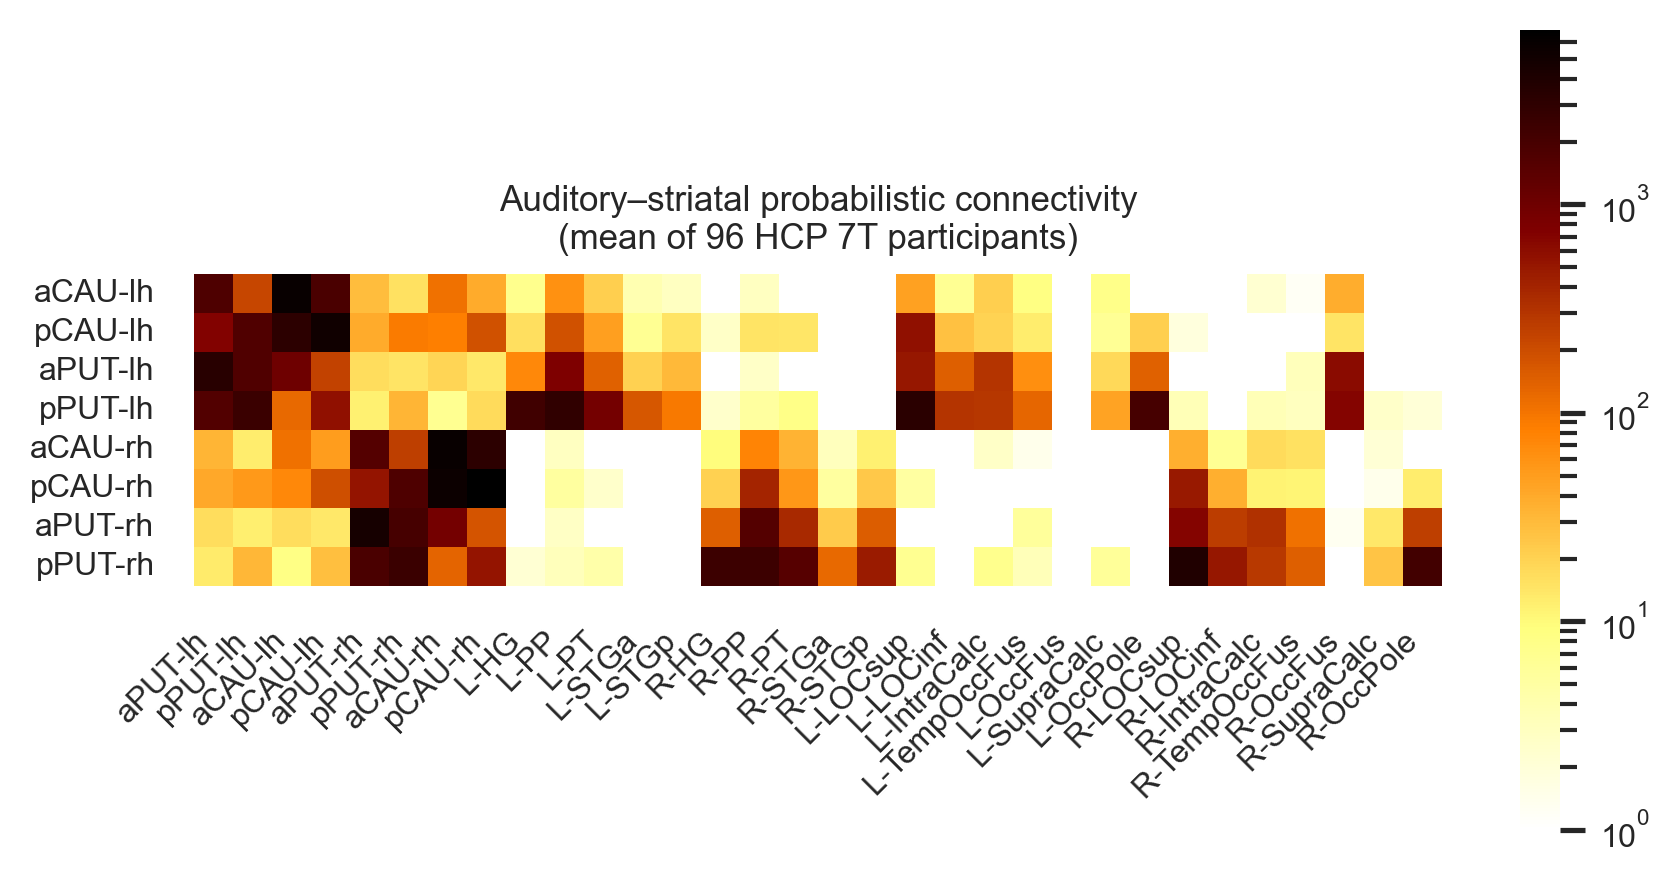

In [50]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

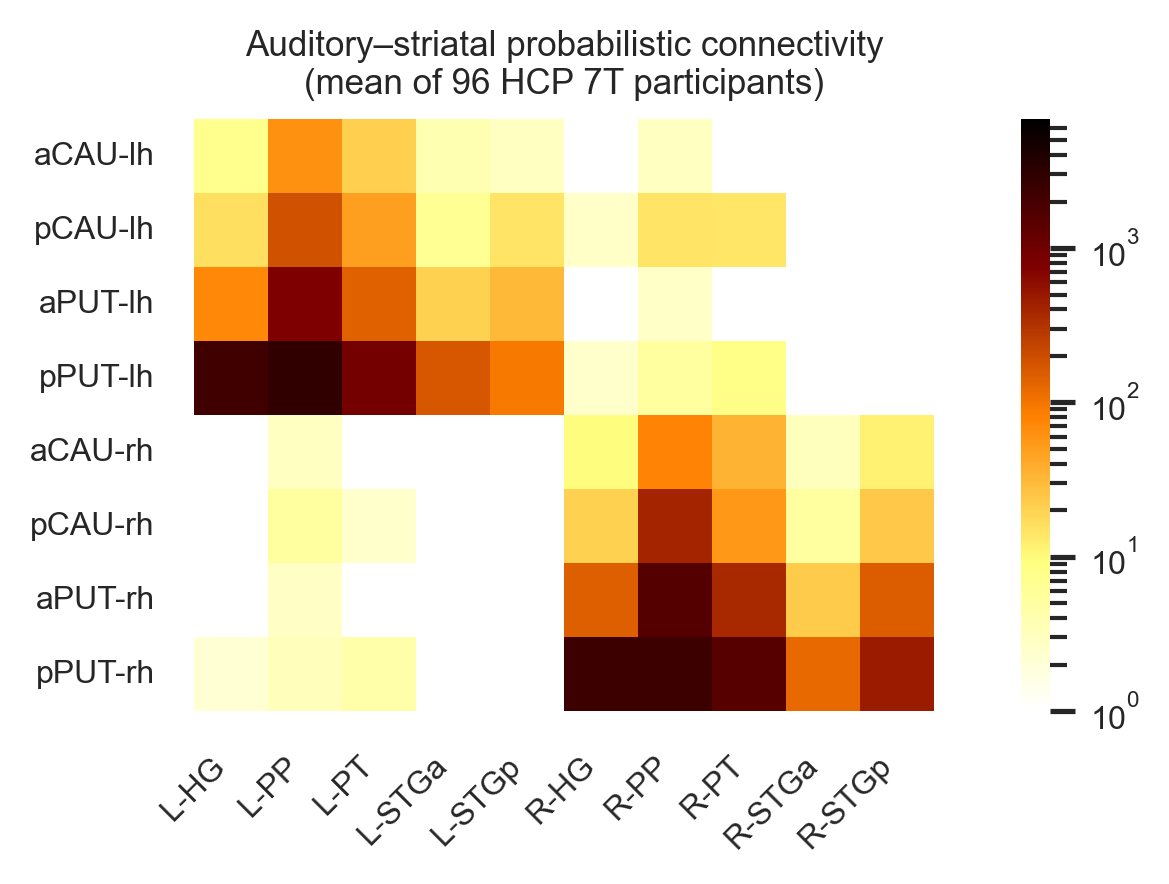

In [51]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df.iloc[:,8:18], ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

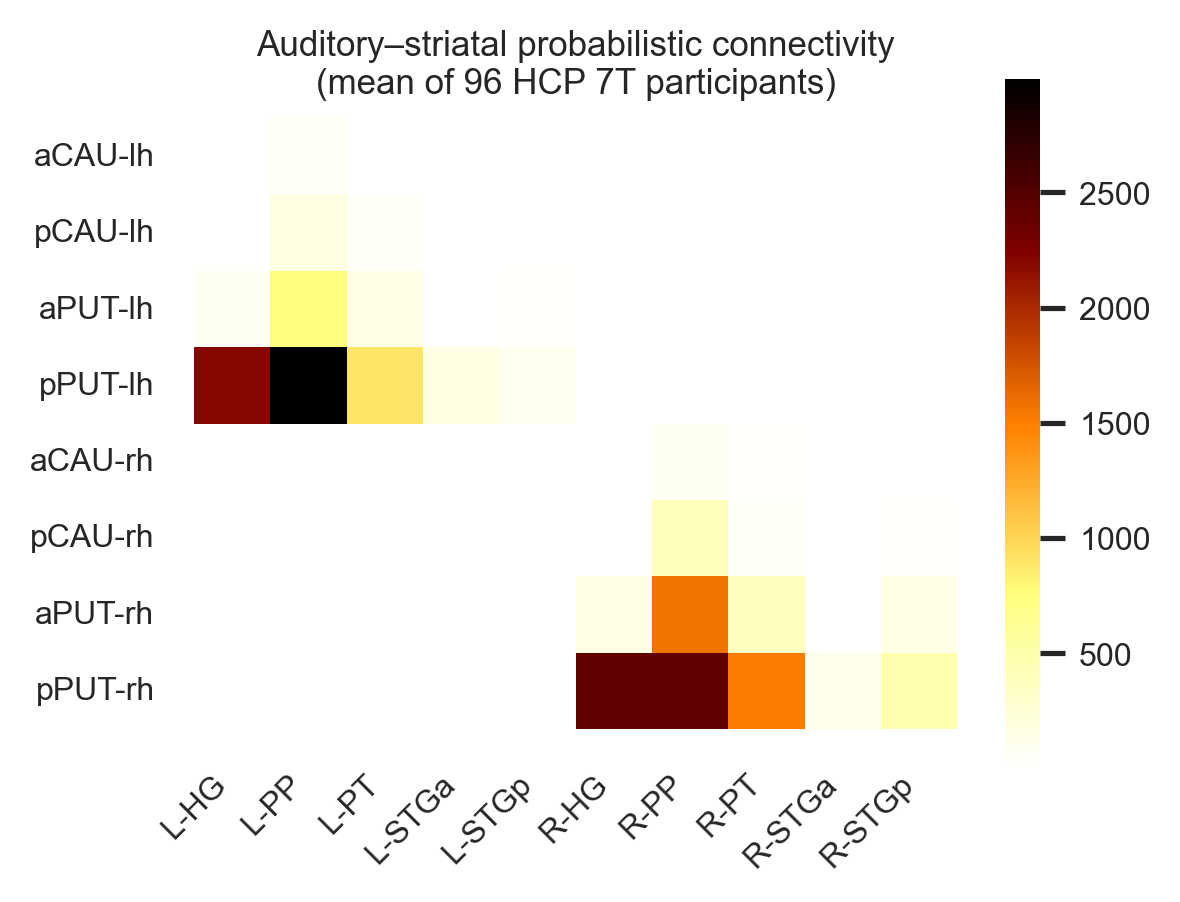

In [52]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(4,3), dpi=300)

sns.heatmap(cs_df.iloc[:,8:18], ax=ax, cmap="afmhot_r",
            #norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

In [45]:
from mne_connectivity.viz import plot_connectivity_circle

In [46]:
cs_df.to_numpy().shape

(8, 32)

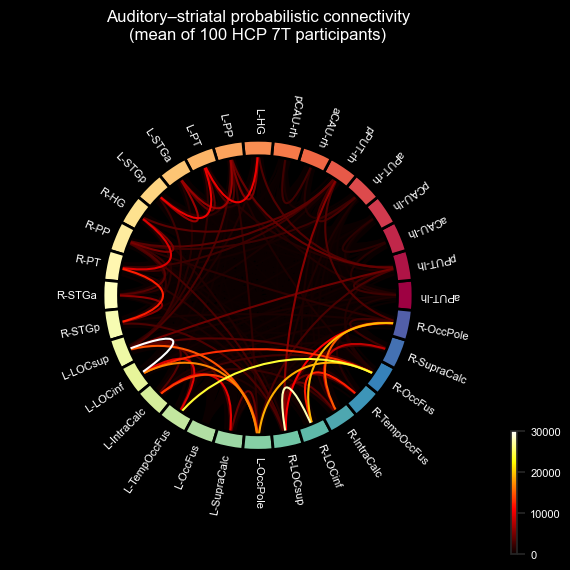

In [47]:
fig, ax = plt.subplots(figsize=(8, 8), facecolor="black", subplot_kw=dict(polar=True))
plot_connectivity_circle(
    plot_df.to_numpy(),
    plot_df.columns,
    #n_lines=300,
    title="Auditory–striatal probabilistic connectivity\n(mean of 100 HCP 7T participants)",
    ax=ax,
)
fig.tight_layout()